In [1]:
import sys
import scanpy as sc
import anndata
import pandas as pd
import numpy as np
import os

data_type = 'float32'

import matplotlib as mpl
from matplotlib import rcParams
import matplotlib.pyplot as plt
import seaborn as sns

# silence scanpy that prints a lot of warnings
import warnings
warnings.filterwarnings('ignore')

In [2]:
from sklearn.metrics import precision_score, recall_score, accuracy_score, fbeta_score
from statistics import mean, stdev
import pickle

In [3]:
# load test sets
file = open('../round_info_0.008_test_sets.save', 'rb')
Round_test_sets = pickle.load(file)
file.close()

file = open('../spermatid_info_0.008_vif_5_test_sets.save', 'rb')
Spermatid_test_sets = pickle.load(file)
file.close()

file = open('../TPC_info_0.008_vif_5_test_sets.save', 'rb')
TPC_test_sets = pickle.load(file)
file.close()

file = open('../Leydig_info_0.02_vif_10_test_sets.save', 'rb')
Leydig_test_sets = pickle.load(file)
file.close()

file = open('../SMC_info_0.025_vif_10_test_sets.save', 'rb')
SMC_test_sets = pickle.load(file)
file.close()

file = open('../Macrophage_info_0.02_vif_10_test_sets.save', 'rb')
Macrophage_test_sets = pickle.load(file)
file.close()

file = open('../Sertoli_info_0.01_vif_5_test_sets.save', 'rb')
Sertoli_test_sets = pickle.load(file)
file.close()

In [4]:
def get_scores_acc(model, test_sets, baseline=False):
    
    scores = []
    for i in range(10):
        X_test, y_test = test_sets[i]
        
        if baseline:
            scores.append(max(y_test.value_counts())/len(y_test))
        
        else:
            clf = model[i]
            y_pred = clf.predict(X_test)
            scores.append(accuracy_score(y_test, y_pred))
        
    print(f'accuracy: {mean(scores)} ± {stdev(scores)}' )
        
    return scores

In [5]:
# load model
file = open('../round_info_0.008.save', 'rb')
Round = pickle.load(file)
file.close()

file = open('../spermatid_info_0.008_vif_5.save', 'rb')
Spermatid = pickle.load(file)
file.close()

file = open('../TPC_info_0.008_vif_5.save', 'rb')
TPC = pickle.load(file)
file.close()

file = open('../Leydig_info_0.02_vif_10.save', 'rb')
Leydig = pickle.load(file)
file.close()

file = open('../SMC_info_0.025_vif_10.save', 'rb')
SMC = pickle.load(file)
file.close()

file = open('../Macrophage_info_0.02_vif_10.save', 'rb')
Macrophage = pickle.load(file)
file.close()

file = open('../Sertoli_info_0.01_vif_5.save', 'rb')
Sertoli = pickle.load(file)
file.close()

In [6]:
print('\nRound scores:')
Round_a = get_scores_acc(Round, Round_test_sets)

print('\nSpermatid scores:')
Spermatid_a = get_scores_acc(Spermatid, Spermatid_test_sets)

print('\nTPC scores:')
TPC_a = get_scores_acc(TPC, TPC_test_sets)

print('\nLeydig scores:')
Leydig_a = get_scores_acc(Leydig, Leydig_test_sets)

print('\nSMC scores:')
SMC_a = get_scores_acc(SMC, SMC_test_sets)

print('\nMacrophage scores:')
Macrophage_a = get_scores_acc(Macrophage, Macrophage_test_sets)

print('\nSertoli scores:')
Sertoli_a = get_scores_acc(Sertoli, Sertoli_test_sets)


Round scores:
accuracy: 0.759618820726623 ± 0.009534443814368066

Spermatid scores:
accuracy: 0.8218312153796025 ± 0.006588433426789487

TPC scores:
accuracy: 0.8814789533560865 ± 0.0029028450565684854

Leydig scores:
accuracy: 0.8435064935064935 ± 0.008668524157781809

SMC scores:
accuracy: 0.7747070985527222 ± 0.013424568279543124

Macrophage scores:
accuracy: 0.839898562975486 ± 0.011356395032496185

Sertoli scores:
accuracy: 0.6966442953020134 ± 0.025468008001356054


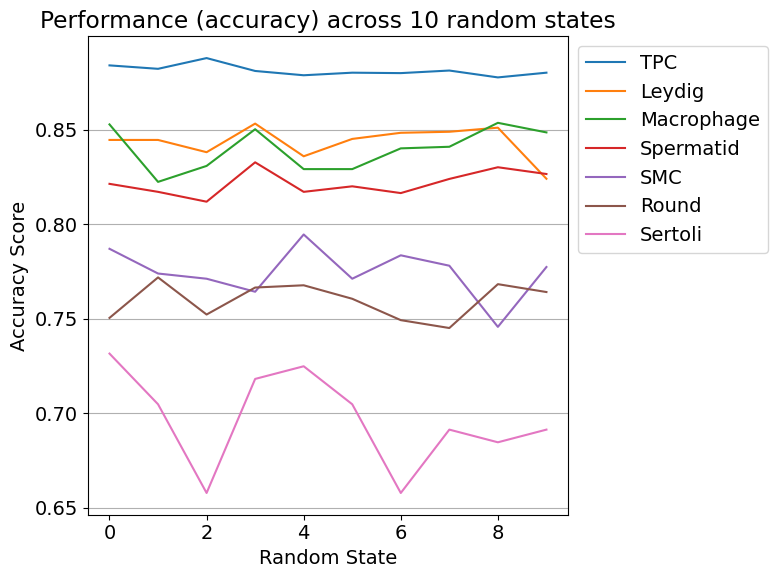

In [7]:
plt.rcParams.update({'font.size': 14})
plt.figure(figsize=(8,6))

plt.plot(TPC_a, label="TPC")
plt.plot(Leydig_a, label="Leydig")
plt.plot(Macrophage_a, label="Macrophage")
plt.plot(Spermatid_a, label="Spermatid")
plt.plot(SMC_a, label="SMC")
plt.plot(Round_a, label="Round")
plt.plot(Sertoli_a, label="Sertoli")


# plt.plot(baseline, label="baseline")

plt.grid(axis='y')
plt.title("Performance (accuracy) across 10 random states")
plt.xlabel("Random State")
plt.ylabel("Accuracy Score")
plt.legend(bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.savefig('../model_comparison.png')
plt.show()

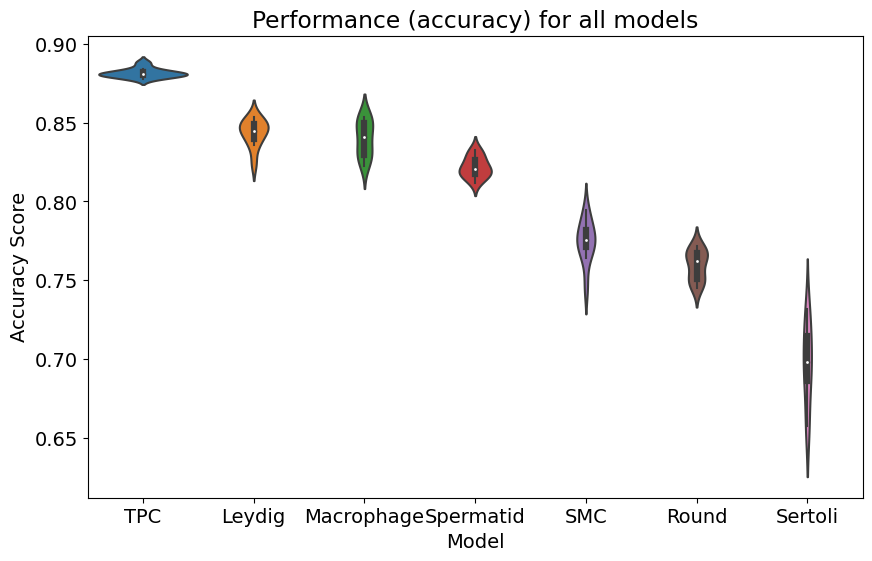

In [8]:
df = {'TPC': TPC_a,
      'Leydig': Leydig_a,
      'Macrophage': Macrophage_a,
      'Spermatid': Spermatid_a,
      'SMC': SMC_a,
      'Round': Round_a,
      'Sertoli': Sertoli_a,
      # 'baseline': baseline
     }

df = pd.DataFrame(df)

plt.figure(figsize=(10,6))

sns.violinplot(data=df)
plt.title('Performance (accuracy) for all models')
plt.xlabel("Model")
plt.ylabel("Accuracy Score")
plt.savefig('../models_violin_acc.png')
plt.show()